# Test model

Loads the trained model from disk and evaluates it: backtests it on the held-out
test period and analyses its predictions on new (out-of-train) data.

In [83]:
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


class CFG:
    # maximum number of simultaneously opened trades
    max_num_simult_trades = 100
    # TP / SL target ratios used to label the data (see target_high_ratio / target_low_ratio
    # in prepare_data.ipynb: 1.05 / 0.95 -> 0.05 / 0.05)
    TP = 0.05
    SL = 0.05
    leverage = 4
    slippage = 0.002
    train_time_years = 4
    test_time_days = 90

## Load the data

In [84]:
from utils.model_train_utils import load_train_data

train_df, test_date = load_train_data(
    "data/train_df.pkl", "data/profitable_hours.csv", CFG.test_time_days
)

## Train the model in inference mode

In [85]:
from utils.optimization_utils import load_best_params
from utils.model_train_utils import (
    load_selected_features,
    model_train,
    prepare_model_params,
)

# best hyperparameters and selected feature set found during optimization
params = load_best_params(row_num=2)
fi = pd.read_csv("model/features/feature_importance.csv")

features, feature_dict = load_selected_features(train_df, params, fi)
params, high_bound, low_bound, sample_weight = prepare_model_params(train_df, params)

with open("model/bybit_tickers.json", "r") as f:
    bybit_tickers = json.load(f)

# train on the 2 years ending test_time_days days before the dataset end, so the last
# test_time_days days stay unseen and can be backtested below
model, _, _, _, _ = model_train(
    train_df,
    features,
    params,
    sample_weight,
    n_folds=8,
    low_bound=low_bound,
    high_bound=high_bound,
    train_test="inference",
    bybit_tickers=bybit_tickers,
    verbose=False,
    train_time_years=CFG.train_time_years,
    test_time_days=CFG.test_time_days,
)

Train on the last 4 years of data up to 2026-03-06 00:00:00
[100]	training's binary_logloss: 0.563845
[200]	training's binary_logloss: 0.534105
[300]	training's binary_logloss: 0.510988
[400]	training's binary_logloss: 0.491907
[500]	training's binary_logloss: 0.472308
[600]	training's binary_logloss: 0.466114
[700]	training's binary_logloss: 0.4526
[800]	training's binary_logloss: 0.443339
[900]	training's binary_logloss: 0.431928
[1000]	training's binary_logloss: 0.423836
[1100]	training's binary_logloss: 0.414686
[1200]	training's binary_logloss: 0.408415
[1300]	training's binary_logloss: 0.401114
[1400]	training's binary_logloss: 0.39079
[1500]	training's binary_logloss: 0.385922
[1600]	training's binary_logloss: 0.377221
[1700]	training's binary_logloss: 0.368778
[1800]	training's binary_logloss: 0.36105
[1900]	training's binary_logloss: 0.353331
[2000]	training's binary_logloss: 0.347378
[2100]	training's binary_logloss: 0.337762
[2200]	training's binary_logloss: 0.330519
[2300]	

## Backtest model

Backtest is run on the held-out **test** period (`time > test_date`) using predictions
from the model loaded from disk.

I don't consider funding fees because they can be both positive and negative. I can do it
because typical funding fee is positive and the majority of my trades are shorts, so I can
even earn on funding. But I think it's better not to consider it at all.

Result balance increase is 102.04%


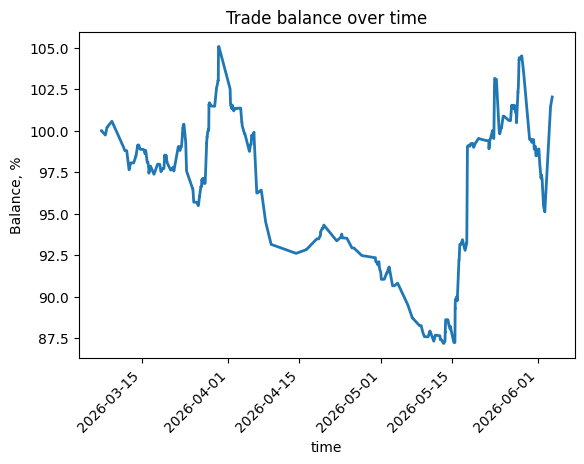

In [86]:
from utils.model_test_utils import backtest

# predict on the test period and backtest those predictions
test_mask = (train_df["ticker"].isin(bybit_tickers)) & (train_df["time"] > test_date)
test_idxs = train_df[test_mask].index
test_pred = model.predict_proba(train_df.loc[test_idxs, features])[:, 1]

result, backtest_df = backtest(
    train_df, 
    test_pred, 
    test_idxs, 
    high_bound, 
    tp=CFG.TP - CFG.slippage,
    sl=CFG.SL + CFG.slippage,
    leverage=CFG.leverage,
    show_progress=False, 
    max_num_simult_trades=CFG.max_num_simult_trades,
)

# plot the balance over time
backtest_plot = backtest_df.set_index("time")["balance"] * 100

print(f"Result balance increase is {round(result, 3)}%")

plt.xlabel("Date")
plt.ylabel("Balance, %")
plt.title("Trade balance over time")
backtest_plot.plot(linewidth=2)
plt.xticks(rotation=45)
plt.show()

## Test model predictions on the new data

List of possible reasons of inconsistence between real and train predictions of tickers

- ticker price doesn't reach the TP or SL thresholds yet

- errors in the data preparation pipeline make model give different predictions

- bot was used in debug mode

- too small volume

- ticker is not presented in bybit_ticker_list due to errors

- ticker was added to exchange not too much time ago

- different high_bound threshold

- different time for prediction

- there are NaNs in the ticker dataframe

- signal was one of the last in the dataframe and was deleted due to signal error protection measures

In [87]:
from utils.model_test_utils import cap_max_num_simult_trades

X = train_df[(train_df["ticker"].isin(bybit_tickers))]
X["pred"] = model.predict_proba(X[features])[:,1]
res = X.loc[((X["pred"] >= high_bound)) & (X["time"] > test_date), ["time", "ticker", "ttype", "pred", "target", "pattern"]]
res = cap_max_num_simult_trades(res, CFG.max_num_simult_trades)
res = res.reset_index(drop=True)
display(res["time"].min(), res["time"].max())
display(res["target"].value_counts())
display(res["target"].value_counts(normalize=True))
display(res[["time", "ticker", "ttype", "pred", "target"]].tail(50))

/tmp/ipykernel_325066/1959248060.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["pred"] = model.predict_proba(X[features])[:,1]


Timestamp('2026-03-06 23:00:00')

Timestamp('2026-06-03 19:00:00')

target
1    503
0    377
Name: count, dtype: int64

target
1    0.571591
0    0.428409
Name: proportion, dtype: float64

,time,ticker,ttype,pred,target
830,2026-06-01 18:00:00,LTCUSDT,buy,0.607561,1
831,2026-06-01 18:00:00,FILUSDT,buy,0.781850,0
832,2026-06-01 18:00:00,SKRUSDT,buy,0.701733,1
833,2026-06-01 18:00:00,AKTUSDT,buy,0.642280,0
834,2026-06-01 18:00:00,FARTCOINUSDT,buy,0.776396,1
835,2026-06-01 18:00:00,SPKUSDT,buy,0.792560,1
836,2026-06-01 18:00:00,SUIUSDT,buy,0.768168,1
837,2026-06-01 18:00:00,MEUSDT,buy,0.749891,1
838,2026-06-01 18:00:00,BABYUSDT,buy,0.699639,1
839,2026-06-01 18:00:00,METUSDT,buy,0.848107,0


### Plot rolling mean precision score of the model predictions for the test data

/tmp/ipykernel_325066/2886128876.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp["ppv_npv_acc"] = tmp["target"].rolling(len(tmp), min_periods=1).count() / (tmp.index + 1)


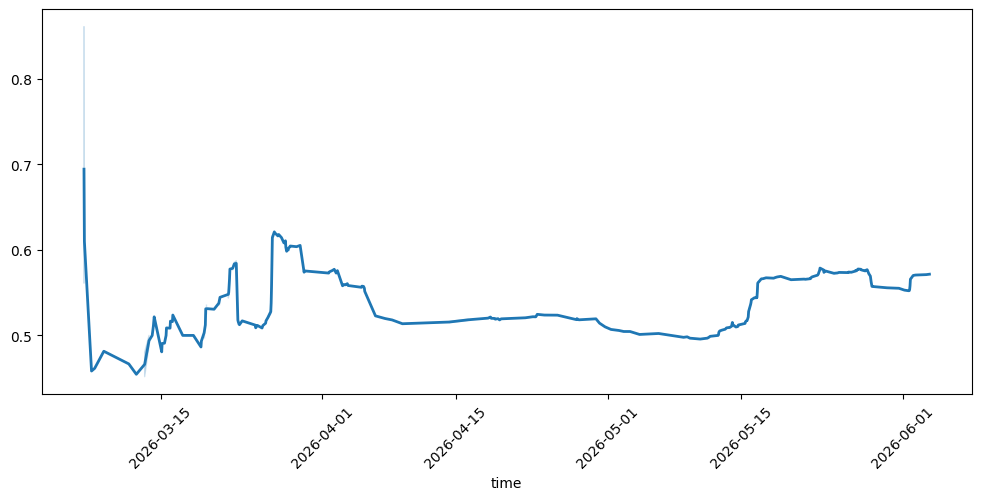

In [88]:
figsize = (12, 5)
plt.figure(figsize=figsize)

tmp = res[res["target"] == 1]

if len(tmp) > 0:
    tmp["ppv_npv_acc"] = tmp["target"].rolling(len(tmp), min_periods=1).count() / (tmp.index + 1)

    ax = sns.lineplot(x=tmp["time"], y=tmp["ppv_npv_acc"].values)
    ax.lines[0].set_linewidth(2)
    plt.xticks(rotation=45)

### Show model uncertainty on the last 90 days of test data

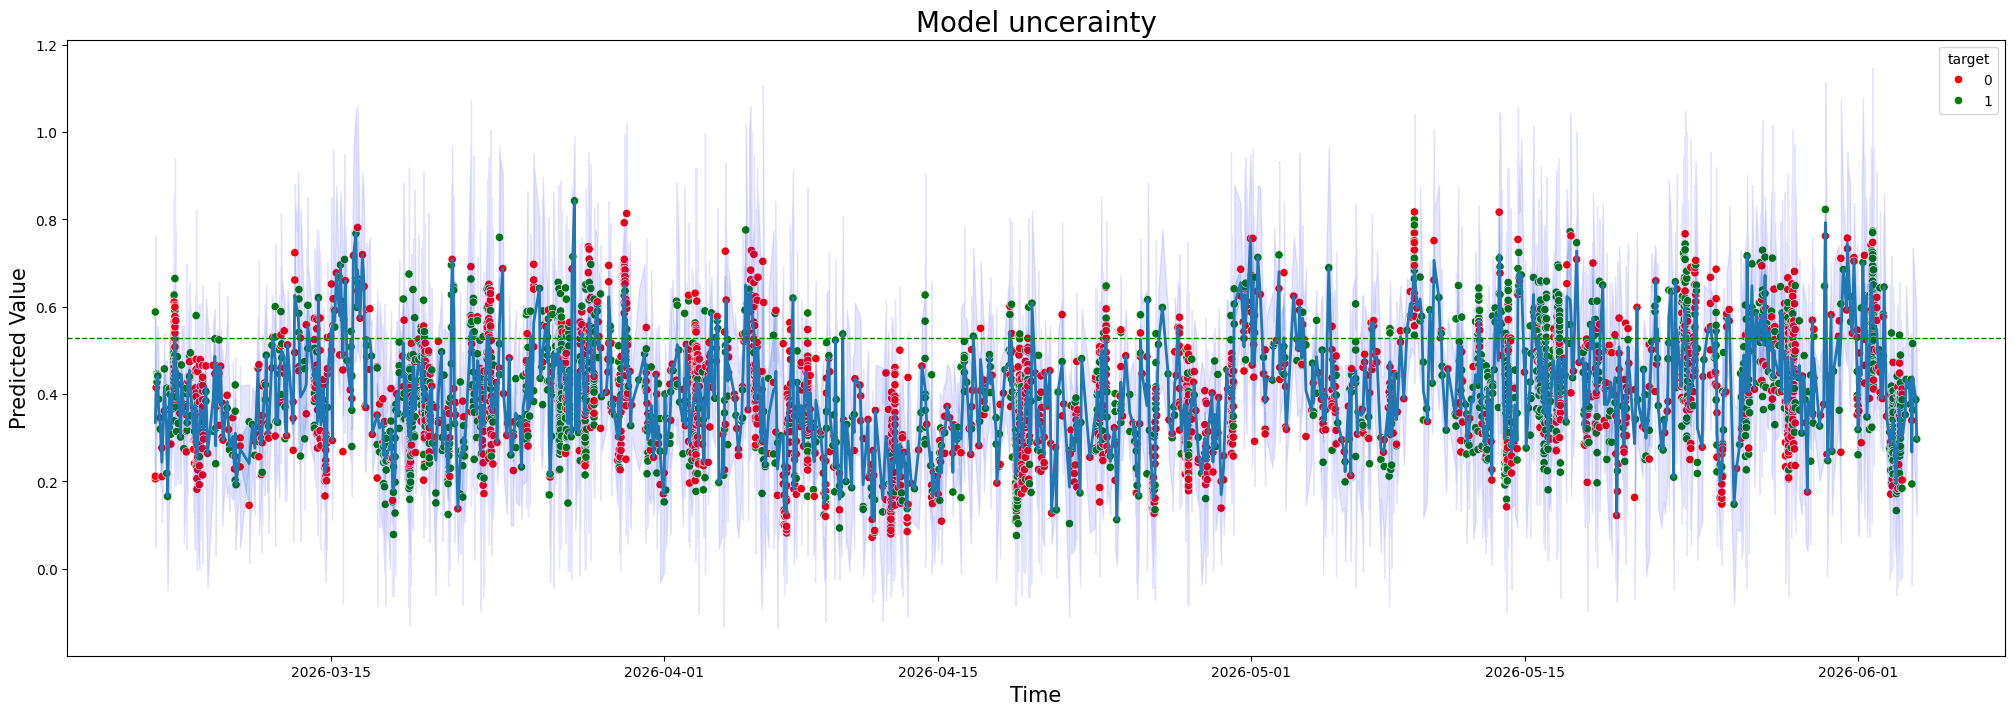

In [89]:
from utils.boosting_uncertainty import predict_with_uncertainty

plot_test_date = train_df["time"].max() - pd.to_timedelta(90, unit="D")
mask = train_df["time"] >= plot_test_date
features_ = train_df.loc[mask, features]
target_ = train_df.loc[mask, "target"]
color = target_.apply(lambda t: "green" if t == 1 else "red")
prediction_dict = predict_with_uncertainty(model, features_, k=20)

ticker = train_df.loc[mask, "ticker"]
time = train_df.loc[mask, "time"]

pred = prediction_dict.pred_virt
lcb = prediction_dict.lcb
ucb = prediction_dict.ucb

plt.figure(figsize=(25, 8))
plt.title("Model uncerainty", fontsize=20)
sns.lineplot(x=time, y=pred, linewidth=2)
plt.axhline(y=high_bound, color="green", linestyle="--", linewidth=1)
sns.scatterplot(x=time, y=pred, hue=target_, palette=["red", "green"])
plt.fill_between(time, lcb, ucb, color='b', alpha=.1)
plt.xlabel("Time", fontsize=15)
plt.ylabel("Predicted Value", fontsize=15);